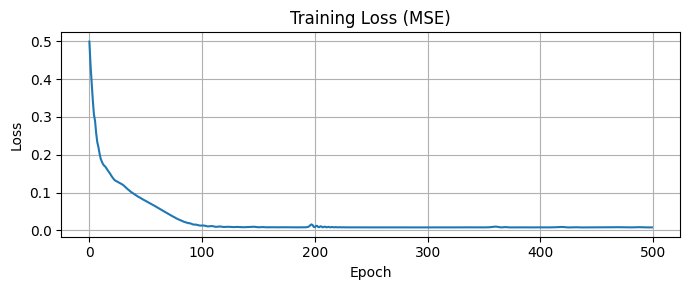

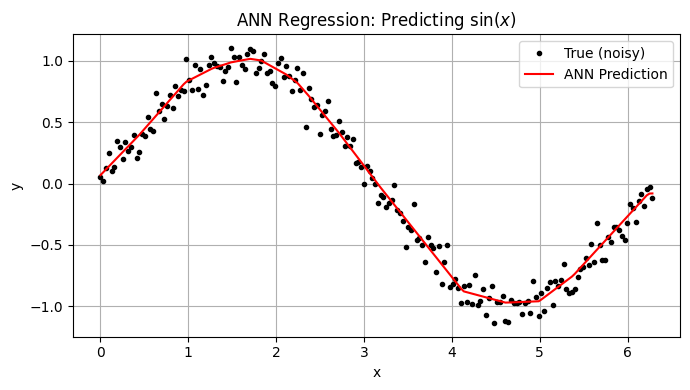

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
x_vals = np.linspace(0, 2*np.pi, 200)
y_vals = np.sin(x_vals) + 0.1 * np.random.randn(*x_vals.shape)

# Convert to PyTorch tensors
X = torch.tensor(x_vals, dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(y_vals, dtype=torch.float32).unsqueeze(1)

# Define ANN model for regression
class ANNRegression(nn.Module):
    def __init__(self):
        super(ANNRegression, self).__init__()
        self.fc1 = nn.Linear(1, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)  # Linear output

# Initialize model
model = ANNRegression()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 500
losses = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X)
    loss = criterion(predictions, Y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Plot training loss curve
plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.title("Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot predictions vs true
model.eval()
with torch.no_grad():
    Y_pred = model(X).squeeze().numpy()

plt.figure(figsize=(7, 4))
plt.plot(x_vals, y_vals, 'k.', label='True (noisy)')
plt.plot(x_vals, Y_pred, 'r-', label='ANN Prediction')
plt.title("ANN Regression: Predicting $\sin(x)$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
